# WESAD Data Exploration

This notebook inventories the WESAD subject folders, inspects the synchronized pickle structure, examines wrist signals and protocol labels, checks data quality, compares baseline, stress and amusement examples, and summarizes all participants.

It intentionally remains an exploration notebook. It does not perform model preprocessing, normalization, resampling, fixed-length window creation, subject splitting, PyTorch `DataLoader` construction, or model training.


## 1. Imports and Project Paths

Paths are derived with `pathlib.Path` so the notebook can be run from `wesad_stress_project/notebooks/` or from the project root.


In [58]:
from pathlib import Path
import sys
import pickle
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
plt.style.use("default")

CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

DATASET_ROOT = PROJECT_ROOT / "data" / "WESAD" / "WESAD"
REPORTS_ROOT = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_ROOT / "tables"
FIGURES_DIR = REPORTS_ROOT / "figures" / "data_exploration"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {DATASET_ROOT.resolve()}")
print(f"Dataset root exists: {DATASET_ROOT.exists()}")

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset root does not exist: {DATASET_ROOT}")


Project root: C:\Users\User\Documents\deep-learning\deep-learning
Project root: C:\Users\User\Documents\deep-learning\deep-learning
Dataset root: C:\Users\User\Documents\deep-learning\deep-learning\data\WESAD\WESAD
Dataset root exists: True


## 2. Constants

These constants describe the expected subject set, wrist sampling frequencies, protocol labels, and the later binary-classification mapping. The binary mapping is used only for preliminary duration summaries in this notebook.


In [59]:
EXPECTED_SUBJECTS = {
    "S2", "S3", "S4", "S5", "S6",
    "S7", "S8", "S9", "S10", "S11",
    "S13", "S14", "S15", "S16", "S17",
}

WRIST_FS = {
    "ACC": 32,
    "BVP": 64,
    "EDA": 4,
    "TEMP": 4,
}

LABEL_FS = 700

LABEL_NAMES = {
    0: "transient/undefined",
    1: "baseline",
    2: "stress",
    3: "amusement",
    4: "meditation",
    5: "ignored",
    6: "ignored",
    7: "ignored",
}

BINARY_LABEL_MAPPING = {
    1: 0,  # baseline -> non-stress
    2: 1,  # stress
    3: 0,  # amusement -> non-stress
}

EXCLUDED_LABELS = {0, 4, 5, 6, 7}
EXAMPLE_SUBJECT = "S2"


## 3. Detect Available Subjects

Subject folders are discovered dynamically and sorted numerically, so `S10` follows `S9`. The inventory records whether the expected companion files are present for each subject.


In [60]:
def subject_sort_key(subject_id: str) -> int:
    """Return the numeric part of a WESAD subject id such as S10."""
    if not subject_id.startswith("S") or not subject_id[1:].isdigit():
        raise ValueError(f"Unexpected subject folder name: {subject_id}")
    return int(subject_id[1:])


def sorted_subject_ids(subject_ids: list[str] | set[str]) -> list[str]:
    return sorted(subject_ids, key=subject_sort_key)


def build_subject_inventory(dataset_root: Path, expected_subjects: set[str]) -> pd.DataFrame:
    discovered_subjects = {
        path.name
        for path in dataset_root.glob("S*")
        if path.is_dir() and path.name[1:].isdigit()
    }
    inventory_subjects = sorted_subject_ids(discovered_subjects | expected_subjects)
    rows = []
    for subject_id in inventory_subjects:
        subject_dir = dataset_root / subject_id
        rows.append(
            {
                "subject": subject_id,
                "folder_exists": subject_dir.is_dir(),
                "pkl_exists": (subject_dir / f"{subject_id}.pkl").exists(),
                "readme_exists": (subject_dir / f"{subject_id}_readme.txt").exists(),
                "questionnaire_exists": (subject_dir / f"{subject_id}_quest.csv").exists(),
                "respiban_exists": (subject_dir / f"{subject_id}_respiban.txt").exists(),
                "e4_zip_exists": (subject_dir / f"{subject_id}_E4_Data.zip").exists(),
            }
        )
    return pd.DataFrame(rows)


subject_dirs = [
    path for path in DATASET_ROOT.glob("S*")
    if path.is_dir() and path.name[1:].isdigit()
]
subjects = sorted_subject_ids([path.name for path in subject_dirs])
subject_inventory = build_subject_inventory(DATASET_ROOT, EXPECTED_SUBJECTS)
subject_inventory_path = TABLES_DIR / "subject_inventory.csv"
subject_inventory.to_csv(subject_inventory_path, index=False)

print(f"Detected {len(subjects)} subject folders: {subjects}")
print(f"Valid subject folders: {int(subject_inventory['folder_exists'].sum())}")
print(f"Saved subject inventory to: {subject_inventory_path}")
display(subject_inventory)


Detected 15 subject folders: ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
Valid subject folders: 15
Saved subject inventory to: C:\Users\User\Documents\deep-learning\deep-learning\reports\tables\subject_inventory.csv


,subject,folder_exists,pkl_exists,readme_exists,questionnaire_exists,respiban_exists,e4_zip_exists
0,S2,True,True,True,True,True,True
1,S3,True,True,True,True,True,True
2,S4,True,True,True,True,True,True
3,S5,True,True,True,True,True,True
4,S6,True,True,True,True,True,True
5,S7,True,True,True,True,True,True
6,S8,True,True,True,True,True,True
7,S9,True,True,True,True,True,True
8,S10,True,True,True,True,True,True
9,S11,True,True,True,True,True,True


The inventory confirms which expected subject folders and companion files are available before any pickle files are loaded.


## 4. Reusable Pickle Loader

The loader keeps pickle handling in one place, uses `latin1` decoding for WESAD compatibility, and validates the minimal synchronized-pickle structure expected by later cells.


In [61]:
def load_wesad_subject(dataset_root: Path, subject_id: str) -> dict:
    """Load one synchronized WESAD subject pickle and validate its top-level structure."""
    subject_pickle_path = dataset_root / subject_id / f"{subject_id}.pkl"
    if not subject_pickle_path.exists():
        raise FileNotFoundError(f"Subject pickle not found: {subject_pickle_path}")

    with subject_pickle_path.open("rb") as file:
        data = pickle.load(file, encoding="latin1")

    if not isinstance(data, dict):
        raise TypeError(f"Expected pickle to contain dict, found {type(data)!r}")

    required_keys = {"signal", "label", "subject"}
    missing_keys = required_keys - set(data.keys())
    if missing_keys:
        raise KeyError(f"Subject {subject_id} is missing keys: {sorted(missing_keys)}")

    return data


## 5. Inspect One Subject

Subject `S2` is loaded as the worked example. Wrist one-dimensional signals are flattened with `reshape(-1)`, while wrist ACC is kept as a three-column array.


In [62]:
subject_data = load_wesad_subject(DATASET_ROOT, EXAMPLE_SUBJECT)
labels = np.asarray(subject_data["label"]).reshape(-1)
wrist_signals_raw = subject_data["signal"]["wrist"]
chest_signals_raw = subject_data["signal"].get("chest", {})

wrist_signals = {
    signal_name: np.asarray(values) if signal_name == "ACC" else np.asarray(values).reshape(-1)
    for signal_name, values in wrist_signals_raw.items()
}

print(f"Loaded example subject: {EXAMPLE_SUBJECT}")
print(f"Top-level dictionary keys: {list(subject_data.keys())}")
print(f"Subject identifier in pickle: {subject_data['subject']}")
print(f"Signal device keys: {list(subject_data['signal'].keys())}")
print(f"Wrist signal keys: {list(wrist_signals_raw.keys())}")
print(f"Chest signal keys: {list(chest_signals_raw.keys())}")

inspection_rows = []
for key, value in subject_data.items():
    inspection_rows.append(
        {
            "location": "top_level",
            "name": key,
            "python_type": type(value).__name__,
            "shape": getattr(value, "shape", None),
            "dtype": getattr(value, "dtype", None),
        }
    )

for signal_name, values in wrist_signals.items():
    array = np.asarray(values)
    inspection_rows.append(
        {
            "location": "signal.wrist",
            "name": signal_name,
            "python_type": type(wrist_signals_raw[signal_name]).__name__,
            "shape": array.shape,
            "dtype": array.dtype,
        }
    )

for signal_name, values in chest_signals_raw.items():
    array = np.asarray(values)
    inspection_rows.append(
        {
            "location": "signal.chest",
            "name": signal_name,
            "python_type": type(values).__name__,
            "shape": array.shape,
            "dtype": array.dtype,
        }
    )

inspection_df = pd.DataFrame(inspection_rows)
display(inspection_df)


C:\Users\User\AppData\Local\Temp\ipykernel_47888\1161222157.py:8: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(file, encoding="latin1")


Loaded example subject: S2
Top-level dictionary keys: ['signal', 'label', 'subject']
Subject identifier in pickle: S2
Signal device keys: ['chest', 'wrist']
Wrist signal keys: ['ACC', 'BVP', 'EDA', 'TEMP']
Chest signal keys: ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']


,location,name,python_type,shape,dtype
0,top_level,signal,dict,None,None
1,top_level,label,ndarray,"(4255300,)",int32
2,top_level,subject,str,None,None
3,signal.wrist,ACC,ndarray,"(194528, 3)",float64
4,signal.wrist,BVP,ndarray,"(389056,)",float64
5,signal.wrist,EDA,ndarray,"(24316,)",float64
6,signal.wrist,TEMP,ndarray,"(24316,)",float64
7,signal.chest,ACC,ndarray,"(4255300, 3)",float64
8,signal.chest,ECG,ndarray,"(4255300, 1)",float64
9,signal.chest,EMG,ndarray,"(4255300, 1)",float64


The synchronized pickle contains protocol labels and device-specific signal dictionaries. Wrist ACC is multichannel; BVP, EDA, and TEMP are single-channel wrist streams sampled at different frequencies.


## 6. Signal-Duration Table

This table compares sample counts, channels, sampling rates, and durations for the S2 wrist streams and protocol labels.


In [63]:
def signal_channel_count(array: np.ndarray) -> int:
    return int(array.shape[1]) if array.ndim > 1 else 1


def signal_duration_row(
    signal_name: str,
    device: str,
    array: np.ndarray,
    sampling_rate_hz: int,
) -> dict[str, Any]:
    return {
        "signal": signal_name,
        "device": device,
        "sampling_rate_hz": sampling_rate_hz,
        "samples": int(array.shape[0]),
        "channels": signal_channel_count(array),
        "duration_seconds": array.shape[0] / sampling_rate_hz,
        "duration_minutes": array.shape[0] / sampling_rate_hz / 60,
        "shape": str(array.shape),
        "dtype": str(array.dtype),
    }


signal_duration_rows = [
    signal_duration_row(signal_name, "wrist", np.asarray(wrist_signals[signal_name]), WRIST_FS[signal_name])
    for signal_name in ["ACC", "BVP", "EDA", "TEMP"]
]
signal_duration_rows.append(signal_duration_row("label", "protocol", labels, LABEL_FS))

signal_duration_df = pd.DataFrame(signal_duration_rows)
display(signal_duration_df)


,signal,device,sampling_rate_hz,samples,channels,duration_seconds,duration_minutes,shape,dtype
0,ACC,wrist,32,194528,3,6079.0,101.316667,"(194528, 3)",float64
1,BVP,wrist,64,389056,1,6079.0,101.316667,"(389056,)",float64
2,EDA,wrist,4,24316,1,6079.0,101.316667,"(24316,)",float64
3,TEMP,wrist,4,24316,1,6079.0,101.316667,"(24316,)",float64
4,label,protocol,700,4255300,1,6079.0,101.316667,"(4255300,)",int32


The wrist streams and labels cover the same recording at different sampling frequencies, so their sample counts differ substantially while durations should be close.


## 7. Data-Quality Checks for S2

The following summary checks for missing and infinite values and reports basic descriptive statistics. ACC is summarized over all three axes together for this broad quality check.


In [64]:
def numeric_array_values(array: np.ndarray) -> np.ndarray:
    """Return a flattened float view for finite-value checks and statistics."""
    return np.asarray(array).reshape(-1).astype(float, copy=False)


def summarize_numeric_array(name: str, device: str, array: np.ndarray) -> dict[str, Any]:
    values = numeric_array_values(array)
    if values.size == 0:
        return {
            "signal": name,
            "device": device,
            "shape": str(np.asarray(array).shape),
            "dtype": str(np.asarray(array).dtype),
            "nan_count": 0,
            "inf_count": 0,
            "minimum": np.nan,
            "maximum": np.nan,
            "mean": np.nan,
            "standard_deviation": np.nan,
        }

    finite_values = values[np.isfinite(values)]
    return {
        "signal": name,
        "device": device,
        "shape": str(np.asarray(array).shape),
        "dtype": str(np.asarray(array).dtype),
        "nan_count": int(np.isnan(values).sum()),
        "inf_count": int(np.isinf(values).sum()),
        "minimum": float(np.min(finite_values)) if finite_values.size else np.nan,
        "maximum": float(np.max(finite_values)) if finite_values.size else np.nan,
        "mean": float(np.mean(finite_values)) if finite_values.size else np.nan,
        "standard_deviation": float(np.std(finite_values)) if finite_values.size else np.nan,
    }


data_quality_rows = [
    summarize_numeric_array(signal_name, "wrist", np.asarray(wrist_signals[signal_name]))
    for signal_name in ["ACC", "BVP", "EDA", "TEMP"]
]
data_quality_rows.append(summarize_numeric_array("label", "protocol", labels))

data_quality_df = pd.DataFrame(data_quality_rows)
display(data_quality_df)


,signal,device,shape,dtype,nan_count,inf_count,minimum,maximum,mean,standard_deviation
0,ACC,wrist,"(194528, 3)",float64,0,0,-128.000000,127.000000,19.428199,31.163864
1,BVP,wrist,"(389056,)",float64,0,0,-873.670000,988.080000,-0.000427,75.871236
2,EDA,wrist,"(24316,)",float64,0,0,0.045113,1.717419,0.391743,0.329229
3,TEMP,wrist,"(24316,)",float64,0,0,32.310000,35.970000,34.386945,1.045318
4,label,protocol,"(4255300,)",int32,0,0,0.000000,7.000000,1.212370,1.606596


NaN and infinite counts should be zero for clean synchronized files. Minima, maxima, means, and standard deviations are descriptive checks only and are not normalization parameters.


## 8. Label Distribution for S2

All protocol labels present in S2 are included, including transient, undefined, meditation, and ignored labels.


In [65]:
def label_distribution_table(labels: np.ndarray, label_sampling_rate: int = LABEL_FS) -> pd.DataFrame:
    flattened_labels = np.asarray(labels).reshape(-1)
    label_counts = pd.Series(flattened_labels).value_counts().sort_index()
    rows = []
    total_samples = int(flattened_labels.shape[0])
    for label_id, sample_count in label_counts.items():
        label_id_int = int(label_id)
        duration_seconds = int(sample_count) / label_sampling_rate
        rows.append(
            {
                "label_id": label_id_int,
                "label_name": LABEL_NAMES.get(label_id_int, "unknown"),
                "sample_count": int(sample_count),
                "duration_seconds": duration_seconds,
                "duration_minutes": duration_seconds / 60,
                "percentage_of_recording": int(sample_count) / total_samples * 100 if total_samples else np.nan,
            }
        )
    return pd.DataFrame(rows)


s2_label_distribution_df = label_distribution_table(labels)
display(s2_label_distribution_df)


,label_id,label_name,sample_count,duration_seconds,duration_minutes,percentage_of_recording
0,0,transient/undefined,2142701,3061.001429,51.016690,50.353700
1,1,baseline,800800,1144.000000,19.066667,18.818885
2,2,stress,430500,615.000000,10.250000,10.116796
3,3,amusement,253400,362.000000,6.033333,5.954927
4,4,meditation,537599,767.998571,12.799976,12.633633
5,6,ignored,45500,65.000000,1.083333,1.069255
6,7,ignored,44800,64.000000,1.066667,1.052805


The label distribution is protocol-level context. Labels 1, 2, and 3 are the future binary-task labels; the other labels remain visible here and are not removed in this exploration notebook.


## 9. Protocol-Label Timeline

The 700 Hz protocol labels are downsampled only for visualization by taking one label value per second.


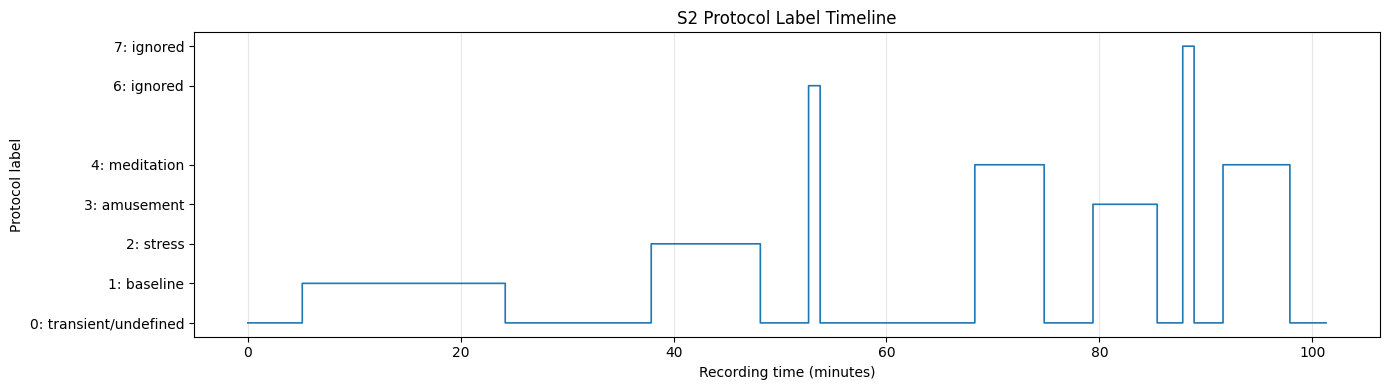

Saved protocol timeline to: C:\Users\User\Documents\deep-learning\deep-learning\reports\figures\data_exploration\S2_protocol_timeline.png


In [66]:
labels_per_second = labels[::LABEL_FS]
time_minutes = np.arange(labels_per_second.shape[0]) / 60
present_label_ids = sorted(int(label_id) for label_id in np.unique(labels_per_second))

fig, ax = plt.subplots(figsize=(14, 4))
ax.step(time_minutes, labels_per_second, where="post", linewidth=1.2)
ax.set_title(f"{EXAMPLE_SUBJECT} Protocol Label Timeline")
ax.set_xlabel("Recording time (minutes)")
ax.set_ylabel("Protocol label")
ax.set_yticks(present_label_ids)
ax.set_yticklabels([f"{label_id}: {LABEL_NAMES.get(label_id, 'unknown')}" for label_id in present_label_ids])
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
protocol_timeline_path = FIGURES_DIR / f"{EXAMPLE_SUBJECT}_protocol_timeline.png"
fig.savefig(protocol_timeline_path, dpi=150)
plt.show()
plt.close(fig)
print(f"Saved protocol timeline to: {protocol_timeline_path}")


The timeline makes protocol ordering and long non-task sections visible without changing the underlying labels used elsewhere in the notebook.


## 10. Signal Plotting Helper

This reusable plotting function handles one-dimensional wrist streams and multidimensional ACC segments.


In [67]:
def plot_signal_segment(
    signal: np.ndarray,
    sampling_rate: int,
    title: str,
    start_sec: float = 0,
    duration_sec: float = 60,
    channel_names: list[str] | None = None,
    save_path: Path | None = None,
) -> None:
    """Plot a requested signal segment using seconds for range selection."""
    if sampling_rate <= 0:
        raise ValueError(f"sampling_rate must be positive, got {sampling_rate}")
    if start_sec < 0:
        raise ValueError(f"start_sec must be non-negative, got {start_sec}")
    if duration_sec <= 0:
        raise ValueError(f"duration_sec must be positive, got {duration_sec}")

    array = np.asarray(signal)
    if array.ndim == 1:
        array_2d = array.reshape(-1, 1)
    elif array.ndim == 2:
        array_2d = array
    else:
        raise ValueError(f"Expected 1D or 2D signal, found shape {array.shape}")

    start_index = int(round(start_sec * sampling_rate))
    stop_index = start_index + int(round(duration_sec * sampling_rate))
    if start_index >= array_2d.shape[0] or stop_index > array_2d.shape[0]:
        available_duration = array_2d.shape[0] / sampling_rate
        raise ValueError(
            f"Requested range {start_sec:.2f}-{start_sec + duration_sec:.2f}s exceeds "
            f"available duration {available_duration:.2f}s"
        )

    segment = array_2d[start_index:stop_index]
    time_seconds = np.arange(start_index, stop_index) / sampling_rate

    if channel_names is not None and len(channel_names) != segment.shape[1]:
        raise ValueError(f"channel_names has length {len(channel_names)}, expected {segment.shape[1]}")

    fig, ax = plt.subplots(figsize=(12, 3.5))
    for channel_index in range(segment.shape[1]):
        label = channel_names[channel_index] if channel_names else f"channel_{channel_index}"
        ax.plot(time_seconds, segment[:, channel_index], linewidth=1, label=label)

    ax.set_title(title)
    ax.set_xlabel("Recording time (seconds)")
    ax.set_ylabel("Signal value")
    if segment.shape[1] > 1 or channel_names is not None:
        ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150)
        print(f"Saved figure to: {save_path}")
    plt.show()
    plt.close(fig)


## 11. Initial Signal Excerpts

The beginning of the recording may correspond to an undefined or transition period. These first-minute plots are therefore mainly basic signal-integrity checks, not condition-specific physiological comparisons.


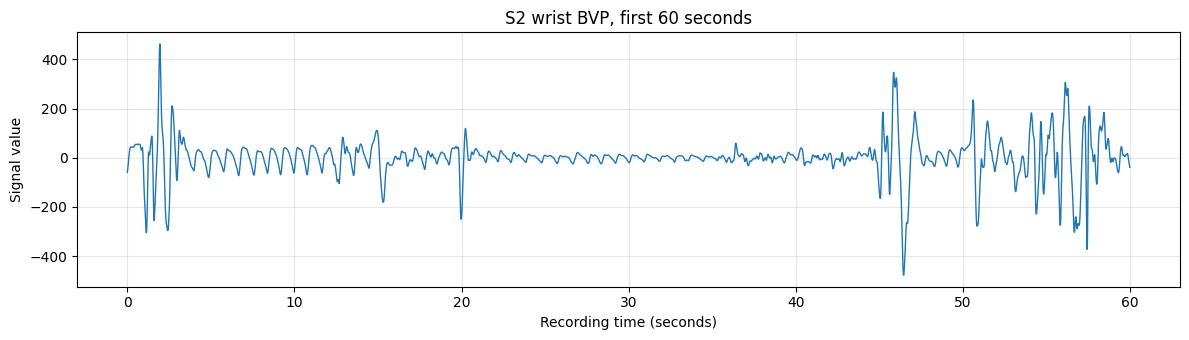

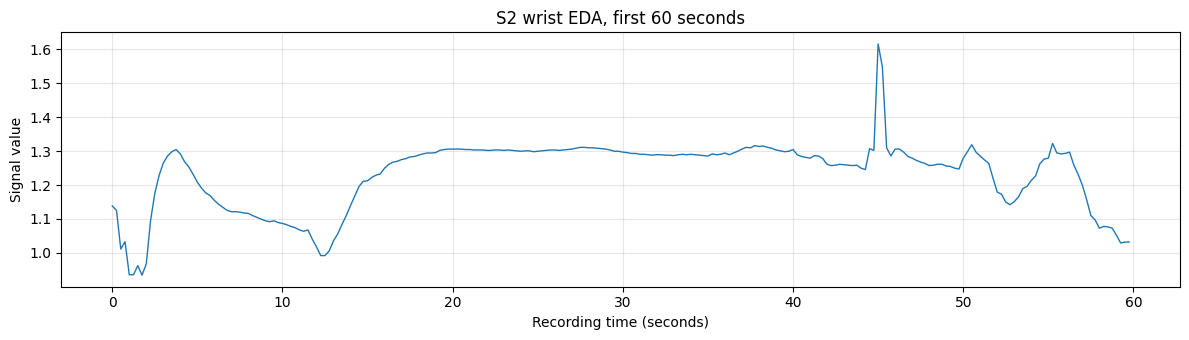

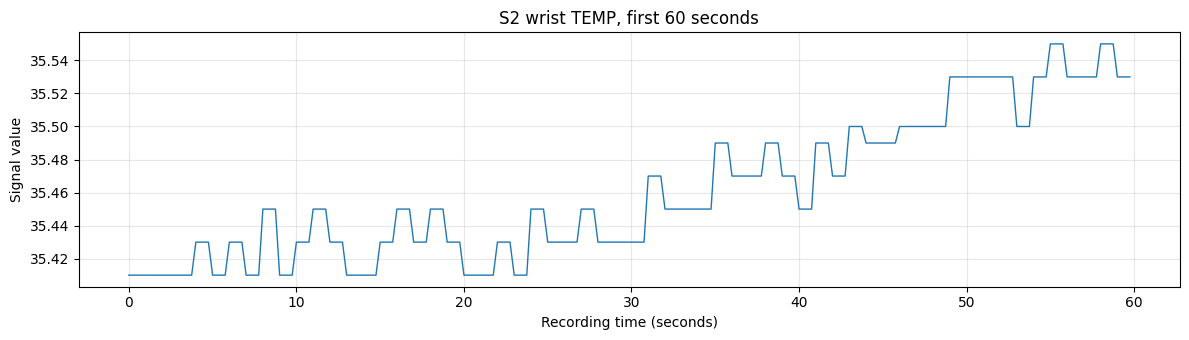

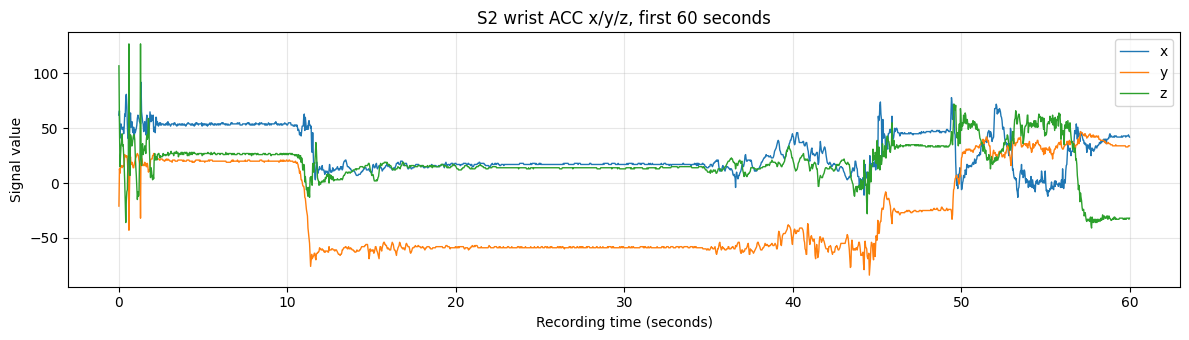

In [68]:
plot_signal_segment(wrist_signals["BVP"], WRIST_FS["BVP"], f"{EXAMPLE_SUBJECT} wrist BVP, first 60 seconds")
plot_signal_segment(wrist_signals["EDA"], WRIST_FS["EDA"], f"{EXAMPLE_SUBJECT} wrist EDA, first 60 seconds")
plot_signal_segment(wrist_signals["TEMP"], WRIST_FS["TEMP"], f"{EXAMPLE_SUBJECT} wrist TEMP, first 60 seconds")
plot_signal_segment(
    wrist_signals["ACC"],
    WRIST_FS["ACC"],
    f"{EXAMPLE_SUBJECT} wrist ACC x/y/z, first 60 seconds",
    channel_names=["x", "y", "z"],
)


The excerpts show whether each wrist modality is present, numerically finite, and plausible over a short raw segment.


## 12. Find Continuous Condition Segments

Condition-specific excerpts are selected from continuous label runs with margins on both sides to avoid transition boundaries.


In [69]:
def find_condition_start(
    labels: np.ndarray,
    label_id: int,
    label_sampling_rate: int = LABEL_FS,
    duration_sec: int = 60,
    margin_sec: int = 5,
) -> float:
    """Return a start time inside a continuous run of label_id with transition margins."""
    flattened_labels = np.asarray(labels).reshape(-1)
    if flattened_labels.size == 0:
        raise ValueError("labels array is empty")
    if label_sampling_rate <= 0:
        raise ValueError("label_sampling_rate must be positive")
    if duration_sec <= 0:
        raise ValueError("duration_sec must be positive")
    if margin_sec < 0:
        raise ValueError("margin_sec must be non-negative")

    is_condition = flattened_labels == label_id
    padded = np.concatenate(([False], is_condition, [False]))
    changes = np.diff(padded.astype(int))
    run_starts = np.flatnonzero(changes == 1)
    run_stops = np.flatnonzero(changes == -1)

    required_samples = int(round((duration_sec + 2 * margin_sec) * label_sampling_rate))
    margin_samples = int(round(margin_sec * label_sampling_rate))

    for run_start, run_stop in zip(run_starts, run_stops):
        if run_stop - run_start >= required_samples:
            return (run_start + margin_samples) / label_sampling_rate

    label_name = LABEL_NAMES.get(label_id, "unknown")
    raise ValueError(
        f"No continuous {duration_sec}s segment with {margin_sec}s margins found "
        f"for label {label_id} ({label_name})."
    )


## 13. Compare Baseline, Stress and Amusement

The next figures compare descriptive 60-second excerpts from clean continuous runs of labels 1, 2, and 3. These are descriptive observations only; visual differences do not prove physiological causality.


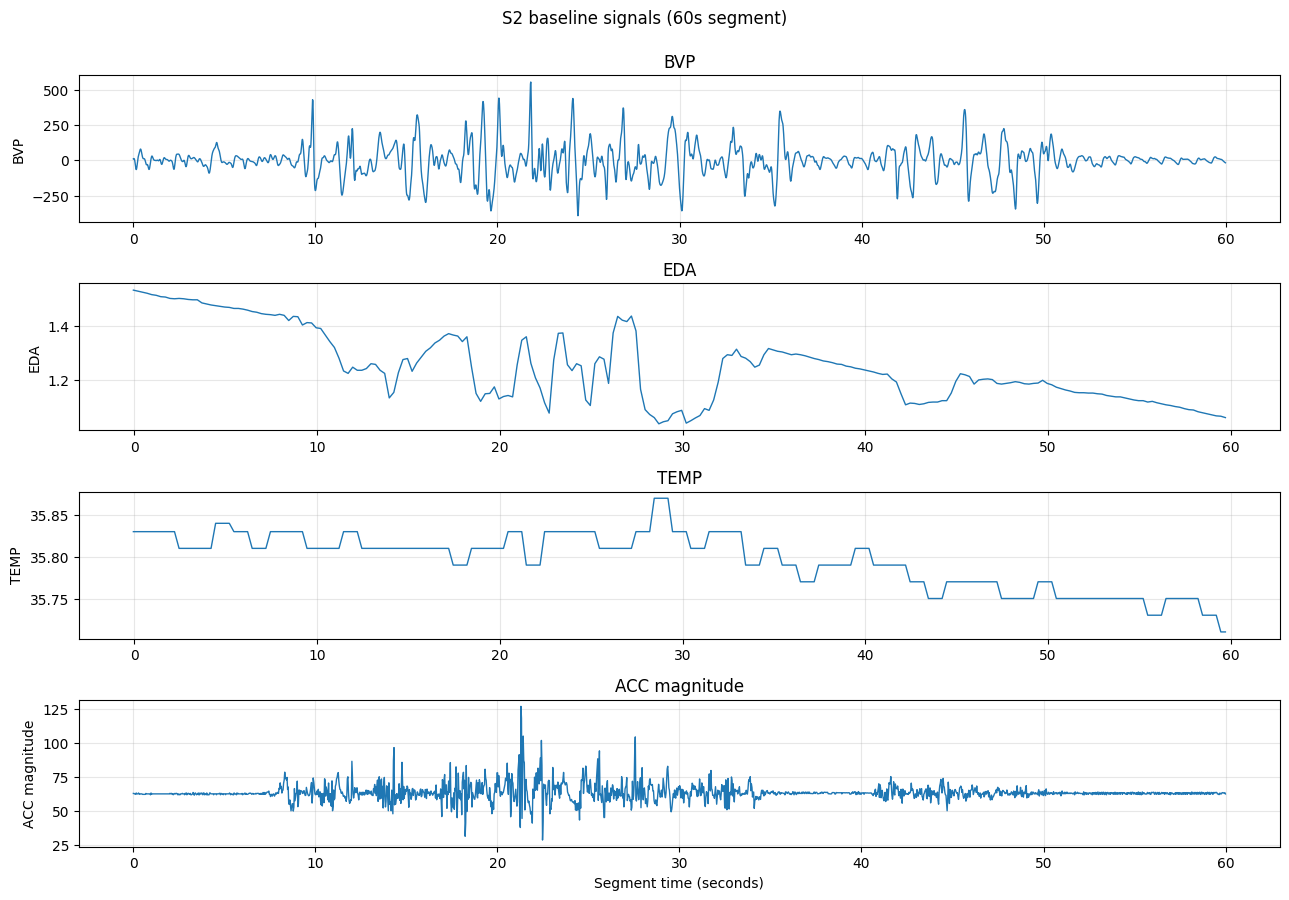

Saved condition figure to: C:\Users\User\Documents\deep-learning\deep-learning\reports\figures\data_exploration\S2_baseline_signals.png


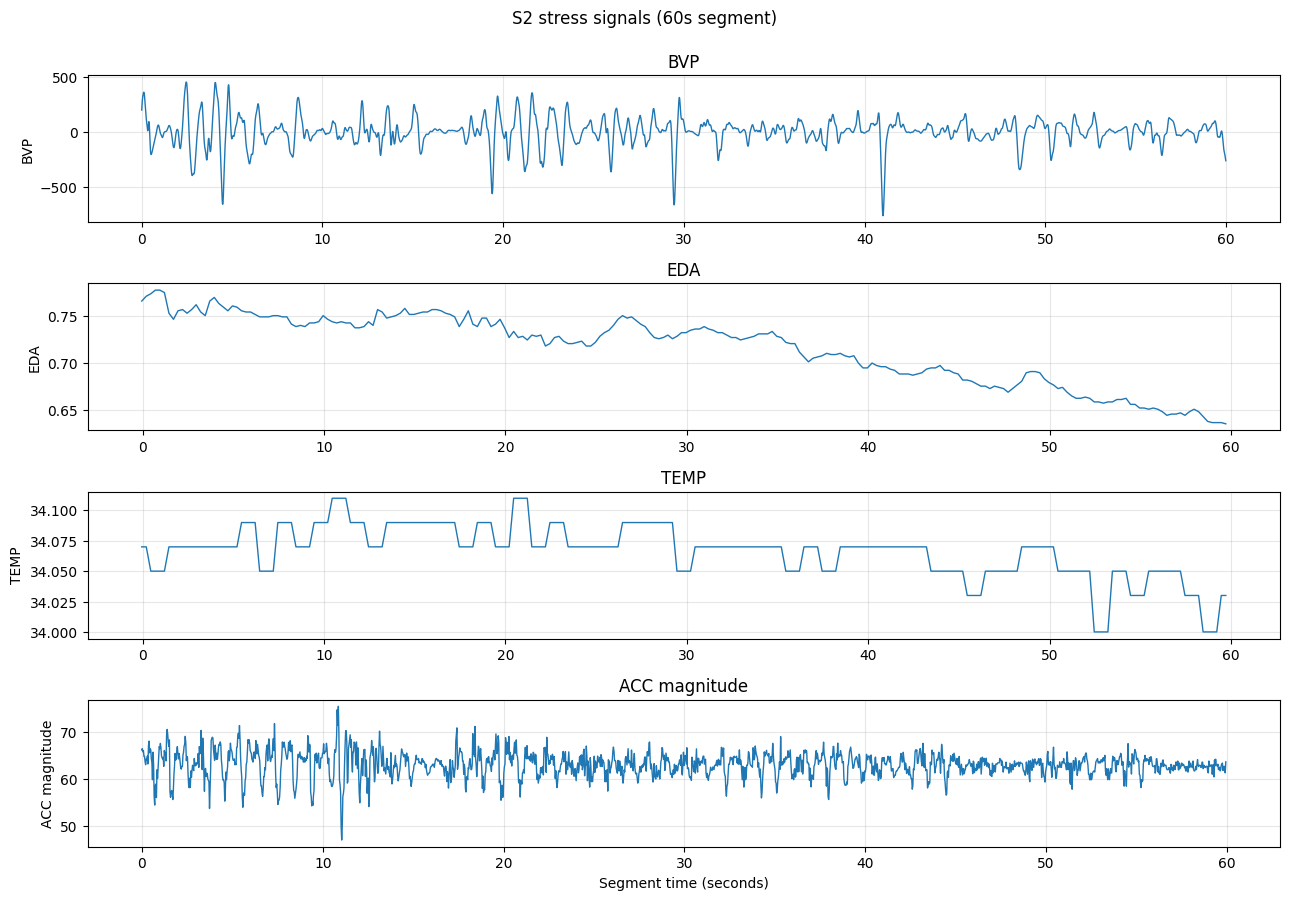

Saved condition figure to: C:\Users\User\Documents\deep-learning\deep-learning\reports\figures\data_exploration\S2_stress_signals.png


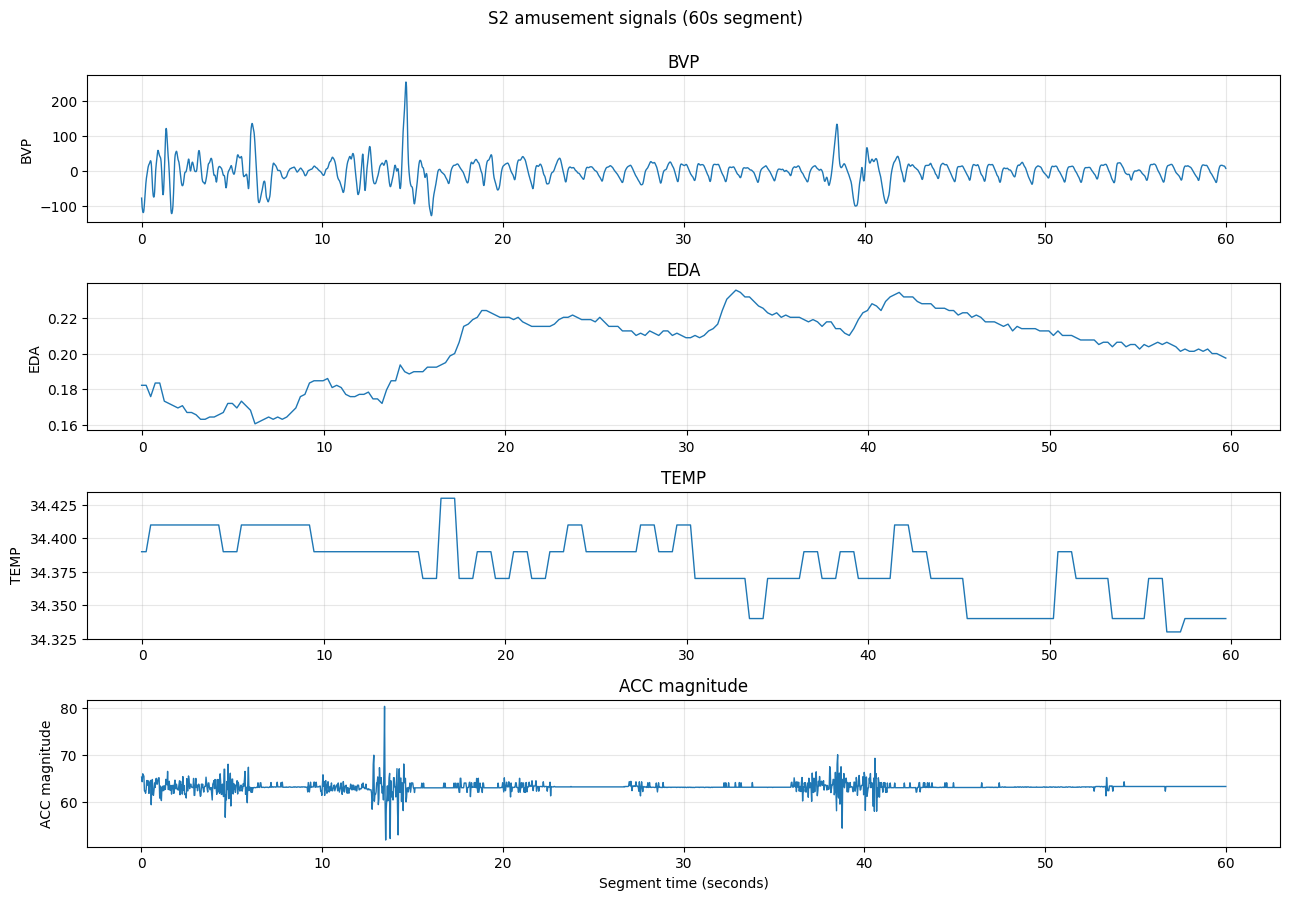

Saved condition figure to: C:\Users\User\Documents\deep-learning\deep-learning\reports\figures\data_exploration\S2_amusement_signals.png


,label_id,label_name,segment_start_seconds
0,1,baseline,311.547143
1,2,stress,2278.545714
2,3,amusement,4768.547143


In [70]:
def acc_magnitude(acc_signal: np.ndarray) -> np.ndarray:
    acc_array = np.asarray(acc_signal)
    if acc_array.ndim != 2 or acc_array.shape[1] != 3:
        raise ValueError(f"ACC must have shape (samples, 3), found {acc_array.shape}")
    return np.sqrt(np.sum(acc_array.astype(float) ** 2, axis=1))


def extract_signal_segment(
    signal: np.ndarray,
    sampling_rate: int,
    start_sec: float,
    duration_sec: float,
) -> tuple[np.ndarray, np.ndarray]:
    array = np.asarray(signal).reshape(-1)
    start_index = int(round(start_sec * sampling_rate))
    stop_index = start_index + int(round(duration_sec * sampling_rate))
    if start_index < 0 or stop_index > array.shape[0]:
        raise ValueError(
            f"Requested segment {start_sec:.2f}-{start_sec + duration_sec:.2f}s exceeds "
            f"signal length {array.shape[0] / sampling_rate:.2f}s"
        )
    time_seconds = np.arange(start_index, stop_index) / sampling_rate
    return time_seconds, array[start_index:stop_index]


def plot_condition_signals(
    subject_id: str,
    wrist_data: dict[str, np.ndarray],
    start_sec: float,
    duration_sec: float,
    condition_name: str,
    save_path: Path,
) -> None:
    """Plot BVP, EDA, TEMP, and ACC magnitude for one condition segment."""
    plot_specs = [
        ("BVP", wrist_data["BVP"], WRIST_FS["BVP"], "BVP"),
        ("EDA", wrist_data["EDA"], WRIST_FS["EDA"], "EDA"),
        ("TEMP", wrist_data["TEMP"], WRIST_FS["TEMP"], "TEMP"),
        ("ACC magnitude", acc_magnitude(wrist_data["ACC"]), WRIST_FS["ACC"], "ACC magnitude"),
    ]

    fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(13, 9), sharex=False)
    for ax, (title, signal_values, sampling_rate, ylabel) in zip(axes, plot_specs):
        time_seconds, segment = extract_signal_segment(signal_values, sampling_rate, start_sec, duration_sec)
        ax.plot(time_seconds - start_sec, segment, linewidth=1)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("Segment time (seconds)")
    fig.suptitle(f"{subject_id} {condition_name} signals ({duration_sec:.0f}s segment)", y=0.995)
    plt.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    plt.close(fig)
    print(f"Saved condition figure to: {save_path}")


condition_segments = []
for label_id in [1, 2, 3]:
    condition_name = LABEL_NAMES[label_id]
    start_sec = find_condition_start(labels, label_id, duration_sec=60, margin_sec=5)
    condition_segments.append(
        {"label_id": label_id, "label_name": condition_name, "segment_start_seconds": start_sec}
    )
    plot_condition_signals(
        EXAMPLE_SUBJECT,
        wrist_signals,
        start_sec=start_sec,
        duration_sec=60,
        condition_name=condition_name,
        save_path=FIGURES_DIR / f"{EXAMPLE_SUBJECT}_{condition_name}_signals.png",
    )

condition_segments_df = pd.DataFrame(condition_segments)
display(condition_segments_df)


These condition excerpts are useful for sanity-checking the synchronized signals and protocol labels. They should not be interpreted as causal evidence or as model-ready segments.


## 14. Duration-Consistency Check

Small duration differences can occur because wrist signals and labels have different sampling frequencies and may end on slightly different sample boundaries.


In [71]:
def calculate_signal_durations(data: dict) -> dict[str, float]:
    """Calculate durations in seconds for labels and expected wrist signals."""
    subject_labels = np.asarray(data["label"]).reshape(-1)
    wrist_data = data["signal"]["wrist"]
    durations = {"labels": subject_labels.shape[0] / LABEL_FS}
    for signal_name, sampling_rate in WRIST_FS.items():
        signal_array = np.asarray(wrist_data[signal_name])
        durations[f"wrist_{signal_name}"] = signal_array.shape[0] / sampling_rate
    return durations


def calculate_duration_difference(data: dict) -> float:
    """Return max duration minus min duration in seconds across labels and wrist signals."""
    durations = calculate_signal_durations(data)
    duration_values = list(durations.values())
    return float(max(duration_values) - min(duration_values))


s2_durations = calculate_signal_durations(subject_data)
s2_duration_difference = calculate_duration_difference(subject_data)

duration_consistency_df = pd.DataFrame(
    [{"stream": stream, "duration_seconds": duration} for stream, duration in s2_durations.items()]
)
display(duration_consistency_df)
print(f"Maximum duration difference for {EXAMPLE_SUBJECT}: {s2_duration_difference:.6f} seconds")


,stream,duration_seconds
0,labels,6079.0
1,wrist_ACC,6079.0
2,wrist_BVP,6079.0
3,wrist_EDA,6079.0
4,wrist_TEMP,6079.0


Maximum duration difference for S2: 0.000000 seconds


The maximum-minus-minimum duration check is a coarse synchronization sanity check across the synchronized labels and wrist modalities.


## 15. Summarize All Subjects

Each participant is summarized with recording duration, label quality, wrist-signal duration and quality, and per-label durations.


In [72]:
def label_column_name(label_id: int) -> str:
    label_name = LABEL_NAMES[label_id].replace("/", "_").replace("-", "_").replace(" ", "_")
    return f"label_{label_id}_{label_name}_minutes"


def summarize_subject(dataset_root: Path, subject_id: str) -> dict[str, Any]:
    """Collect exploration-level summary statistics for one WESAD subject."""
    data = load_wesad_subject(dataset_root, subject_id)
    subject_labels = np.asarray(data["label"]).reshape(-1)
    label_values = numeric_array_values(subject_labels)
    label_counts = pd.Series(subject_labels).value_counts().sort_index()
    wrist_data = data["signal"]["wrist"]

    row: dict[str, Any] = {
        "subject": subject_id,
        "recording_duration_minutes": subject_labels.shape[0] / LABEL_FS / 60,
        "label_samples": int(subject_labels.shape[0]),
        "label_nan_count": int(np.isnan(label_values).sum()),
        "label_inf_count": int(np.isinf(label_values).sum()),
        "max_duration_difference_sec": calculate_duration_difference(data),
    }

    for signal_name, sampling_rate in WRIST_FS.items():
        signal_array = np.asarray(wrist_data[signal_name])
        signal_values = numeric_array_values(signal_array)
        row[f"wrist_{signal_name}_samples"] = int(signal_array.shape[0])
        row[f"wrist_{signal_name}_channels"] = signal_channel_count(signal_array)
        row[f"wrist_{signal_name}_duration_minutes"] = signal_array.shape[0] / sampling_rate / 60
        row[f"wrist_{signal_name}_nan_count"] = int(np.isnan(signal_values).sum())
        row[f"wrist_{signal_name}_inf_count"] = int(np.isinf(signal_values).sum())

    for label_id in LABEL_NAMES:
        sample_count = int(label_counts.get(label_id, 0))
        row[label_column_name(label_id)] = sample_count / LABEL_FS / 60

    return row


subject_summary_df = pd.DataFrame([summarize_subject(DATASET_ROOT, subject_id) for subject_id in subjects])
subject_summary_path = TABLES_DIR / "subject_summary.csv"
subject_summary_df.to_csv(subject_summary_path, index=False)

print(f"Saved subject summary to: {subject_summary_path}")
display(subject_summary_df)


C:\Users\User\AppData\Local\Temp\ipykernel_47888\1161222157.py:8: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(file, encoding="latin1")


Saved subject summary to: C:\Users\User\Documents\deep-learning\deep-learning\reports\tables\subject_summary.csv


,subject,recording_duration_minutes,label_samples,label_nan_count,label_inf_count,max_duration_difference_sec,wrist_ACC_samples,wrist_ACC_channels,wrist_ACC_duration_minutes,wrist_ACC_nan_count,wrist_ACC_inf_count,wrist_BVP_samples,wrist_BVP_channels,wrist_BVP_duration_minutes,wrist_BVP_nan_count,wrist_BVP_inf_count,wrist_EDA_samples,wrist_EDA_channels,wrist_EDA_duration_minutes,wrist_EDA_nan_count,wrist_EDA_inf_count,wrist_TEMP_samples,wrist_TEMP_channels,wrist_TEMP_duration_minutes,wrist_TEMP_nan_count,wrist_TEMP_inf_count,label_0_transient_undefined_minutes,label_1_baseline_minutes,label_2_stress_minutes,label_3_amusement_minutes,label_4_meditation_minutes,label_5_ignored_minutes,label_6_ignored_minutes,label_7_ignored_minutes
0,S2,101.316667,4255300,0,0,0.0,194528,3,101.316667,0,0,389056,1,101.316667,0,0,24316,1,101.316667,0,0,24316,1,101.316667,0,0,51.016690,19.066667,10.250000,6.033333,12.799976,0.000000,1.083333,1.066667
1,S3,108.216667,4545100,0,0,0.0,207776,3,108.216667,0,0,415552,1,108.216667,0,0,25972,1,108.216667,0,0,25972,1,108.216667,0,0,55.849976,19.000000,10.666667,6.250000,13.000024,1.216667,1.116667,1.116667
2,S4,107.050000,4496100,0,0,0.0,205536,3,107.050000,0,0,411072,1,107.050000,0,0,25692,1,107.050000,0,0,25692,1,107.050000,0,0,55.099976,19.300024,10.583333,6.200000,13.416667,0.849976,0.733333,0.866690
3,S5,104.300000,4380600,0,0,0.0,200256,3,104.300000,0,0,400512,1,104.300000,0,0,25032,1,104.300000,0,0,25032,1,104.300000,0,0,51.016667,19.966667,10.750000,6.233333,13.233333,1.200024,0.733310,1.166667
4,S6,117.850000,4949700,0,0,0.0,226272,3,117.850000,0,0,452544,1,117.850000,0,0,28284,1,117.850000,0,0,28284,1,117.850000,0,0,65.083310,19.666667,10.833333,6.200000,13.116667,0.966667,0.833357,1.150000
5,S7,87.300000,3666600,0,0,0.0,167616,3,87.300000,0,0,335232,1,87.300000,0,0,20952,1,87.300000,0,0,20952,1,87.300000,0,0,35.049952,19.766667,10.666667,6.200024,13.166690,0.833333,0.733310,0.883357
6,S8,91.100000,3826200,0,0,0.0,174912,3,91.100000,0,0,349824,1,91.100000,0,0,21864,1,91.100000,0,0,21864,1,91.100000,0,0,38.483333,19.483333,11.166667,6.166643,13.266667,0.816667,0.850024,0.866667
7,S9,87.050000,3656100,0,0,0.0,167136,3,87.050000,0,0,334272,1,87.050000,0,0,20892,1,87.050000,0,0,20892,1,87.050000,0,0,34.183333,19.666667,10.750000,6.200000,13.216667,1.000000,1.033333,1.000000
8,S10,91.600000,3847200,0,0,0.0,175872,3,91.600000,0,0,351744,1,91.600000,0,0,21984,1,91.600000,0,0,21984,1,91.600000,0,0,37.833333,19.666667,12.083333,6.200000,13.266667,0.850000,0.750000,0.950000
9,S11,87.216667,3663100,0,0,0.0,167456,3,87.216667,0,0,334912,1,87.216667,0,0,20932,1,87.216667,0,0,20932,1,87.216667,0,0,34.366667,19.666667,11.333333,6.133333,13.183357,0.833333,0.866643,0.833333


The all-subject summary supports quick checks for missing values, unexpected channel counts, and large duration mismatches before any preprocessing decisions are made.


## 16. All-Subject Label-Duration Table

The long-format label-duration table is easier to plot and audit than wide per-subject columns.


Saved label-duration table to: C:\Users\User\Documents\deep-learning\deep-learning\reports\tables\label_duration_by_subject.csv


,subject,label_id,label_name,duration_seconds,duration_minutes,percentage_of_subject_recording
0,S2,0,transient/undefined,3061.001429,51.016690,50.353700
1,S2,1,baseline,1144.000000,19.066667,18.818885
2,S2,2,stress,615.000000,10.250000,10.116796
3,S2,3,amusement,362.000000,6.033333,5.954927
4,S2,4,meditation,767.998571,12.799976,12.633633
5,S2,5,ignored,0.000000,0.000000,0.000000
6,S2,6,ignored,65.000000,1.083333,1.069255
7,S2,7,ignored,64.000000,1.066667,1.052805
8,S3,0,transient/undefined,3350.998571,55.849976,51.609404
9,S3,1,baseline,1140.000000,19.000000,17.557369


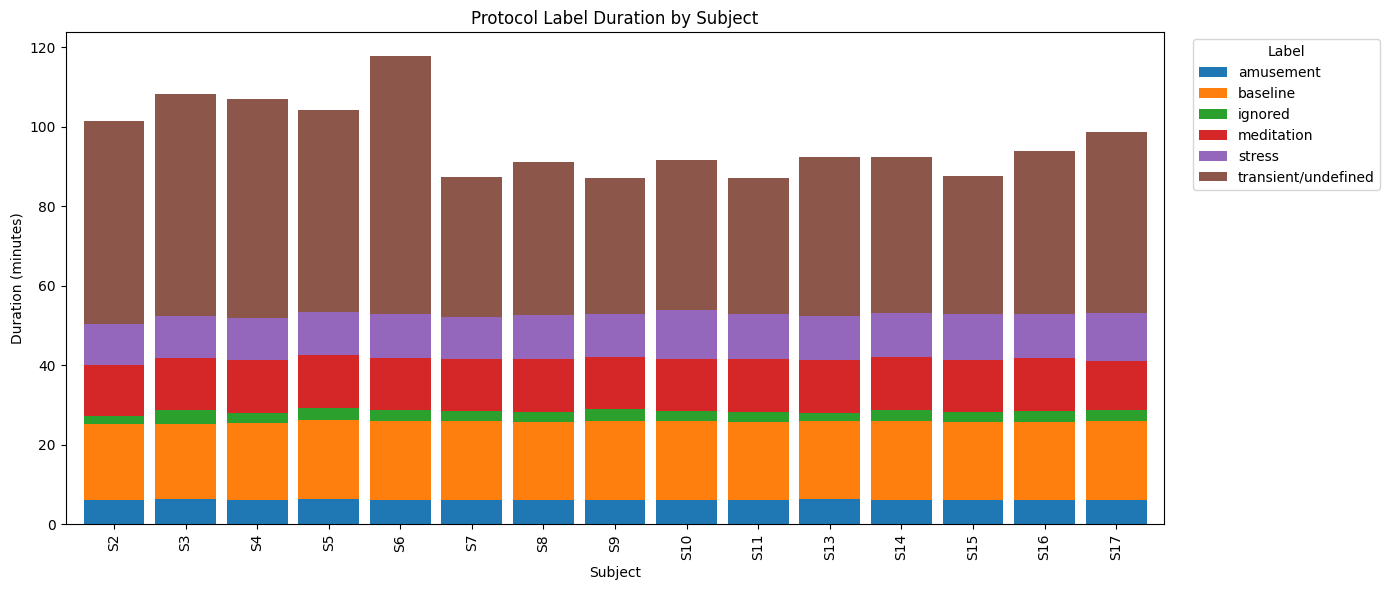

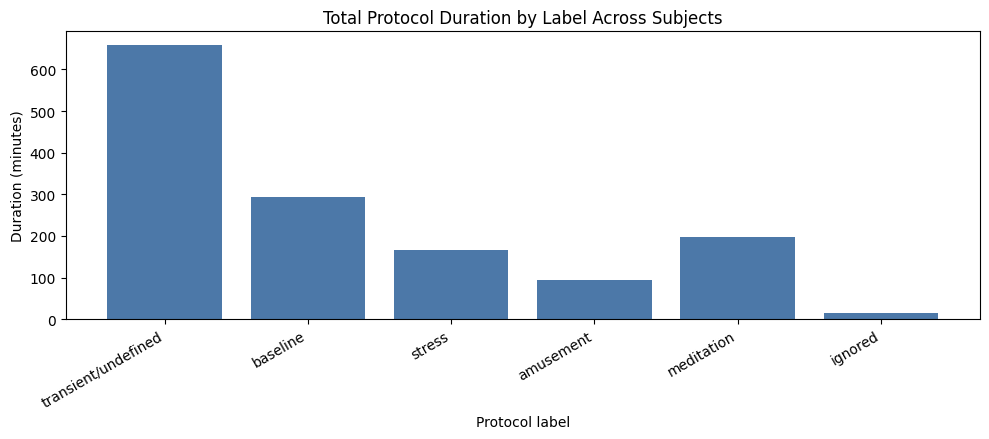

Saved label-duration plots to: C:\Users\User\Documents\deep-learning\deep-learning\reports\figures\data_exploration\label_duration_by_subject.png and C:\Users\User\Documents\deep-learning\deep-learning\reports\figures\data_exploration\total_duration_by_label.png


In [73]:
def build_label_duration_by_subject(subject_summary: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, subject_row in subject_summary.iterrows():
        total_minutes = float(subject_row["recording_duration_minutes"])
        for label_id, label_name in LABEL_NAMES.items():
            duration_minutes = float(subject_row[label_column_name(label_id)])
            rows.append(
                {
                    "subject": subject_row["subject"],
                    "label_id": label_id,
                    "label_name": label_name,
                    "duration_seconds": duration_minutes * 60,
                    "duration_minutes": duration_minutes,
                    "percentage_of_subject_recording": duration_minutes / total_minutes * 100 if total_minutes else np.nan,
                }
            )
    return pd.DataFrame(rows)


label_duration_by_subject_df = build_label_duration_by_subject(subject_summary_df)
label_duration_by_subject_path = TABLES_DIR / "label_duration_by_subject.csv"
label_duration_by_subject_df.to_csv(label_duration_by_subject_path, index=False)

print(f"Saved label-duration table to: {label_duration_by_subject_path}")
display(label_duration_by_subject_df.head(20))

label_pivot = label_duration_by_subject_df.pivot_table(
    index="subject",
    columns="label_name",
    values="duration_minutes",
    aggfunc="sum",
    fill_value=0,
)
label_pivot = label_pivot.reindex(index=subjects)

fig, ax = plt.subplots(figsize=(14, 6))
label_pivot.plot(kind="bar", stacked=True, ax=ax, width=0.85)
ax.set_title("Protocol Label Duration by Subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Duration (minutes)")
ax.legend(title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
label_by_subject_plot_path = FIGURES_DIR / "label_duration_by_subject.png"
fig.savefig(label_by_subject_plot_path, dpi=150)
plt.show()
plt.close(fig)

label_totals = (
    label_duration_by_subject_df.groupby(["label_id", "label_name"], as_index=False)["duration_minutes"]
    .sum()
    .sort_values("label_id")
)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(label_totals["label_name"], label_totals["duration_minutes"], color="#4C78A8")
ax.set_title("Total Protocol Duration by Label Across Subjects")
ax.set_xlabel("Protocol label")
ax.set_ylabel("Duration (minutes)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
total_label_plot_path = FIGURES_DIR / "total_duration_by_label.png"
fig.savefig(total_label_plot_path, dpi=150)
plt.show()
plt.close(fig)

print(f"Saved label-duration plots to: {label_by_subject_plot_path} and {total_label_plot_path}")


The stacked plot compares protocol composition by participant, while the total-duration plot shows which labels dominate the dataset overall.


## 17. Preliminary Binary Duration Distribution

The later binary task maps baseline and amusement to non-stress and stress to stress. This cell uses that mapping only for duration-level exploration.

> This is a duration-level distribution before resampling and fixed-length window creation. The class distribution relevant to model training will be recalculated after windows have been created in `01_preprocessing_and_splits.ipynb`.


In [74]:
def build_binary_duration_distribution(subject_summary: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, subject_row in subject_summary.iterrows():
        baseline_minutes = float(subject_row[label_column_name(1)])
        stress_minutes = float(subject_row[label_column_name(2)])
        amusement_minutes = float(subject_row[label_column_name(3)])
        non_stress_minutes = baseline_minutes + amusement_minutes
        binary_total_minutes = non_stress_minutes + stress_minutes
        rows.append(
            {
                "subject": subject_row["subject"],
                "baseline_minutes": baseline_minutes,
                "stress_minutes": stress_minutes,
                "amusement_minutes": amusement_minutes,
                "non_stress_minutes": non_stress_minutes,
                "stress_percentage": stress_minutes / binary_total_minutes * 100 if binary_total_minutes else np.nan,
                "non_stress_percentage": non_stress_minutes / binary_total_minutes * 100 if binary_total_minutes else np.nan,
            }
        )
    return pd.DataFrame(rows)


binary_duration_df = build_binary_duration_distribution(subject_summary_df)
binary_duration_path = TABLES_DIR / "binary_duration_distribution.csv"
binary_duration_df.to_csv(binary_duration_path, index=False)

print(f"Saved binary duration distribution to: {binary_duration_path}")
display(binary_duration_df)


Saved binary duration distribution to: C:\Users\User\Documents\deep-learning\deep-learning\reports\tables\binary_duration_distribution.csv


,subject,baseline_minutes,stress_minutes,amusement_minutes,non_stress_minutes,stress_percentage,non_stress_percentage
0,S2,19.066667,10.250000,6.033333,25.100000,28.995757,71.004243
1,S3,19.000000,10.666667,6.250000,25.250000,29.698376,70.301624
2,S4,19.300024,10.583333,6.200000,25.500024,29.330235,70.669765
3,S5,19.966667,10.750000,6.233333,26.200000,29.093369,70.906631
4,S6,19.666667,10.833333,6.200000,25.866667,29.518619,70.481381
5,S7,19.766667,10.666667,6.200024,25.966690,29.117361,70.882639
6,S8,19.483333,11.166667,6.166643,25.649976,30.330486,69.669514
7,S9,19.666667,10.750000,6.200000,25.866667,29.358216,70.641784
8,S10,19.666667,12.083333,6.200000,25.866667,31.840141,68.159859
9,S11,19.666667,11.333333,6.133333,25.800000,30.520646,69.479354


This preliminary table describes only the raw protocol duration that would be eligible for the future binary task. It is not a model-training class distribution.


## 18. Dataset-Level Binary Summary

The total binary-duration summary aggregates baseline plus amusement as non-stress and compares that duration with stress.


,class_name,duration_minutes,percentage
0,non-stress,386.433405,69.938466
1,stress,166.100024,30.061534


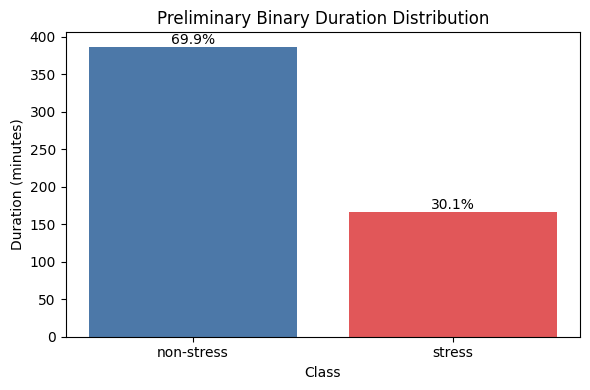

Saved binary duration plot to: C:\Users\User\Documents\deep-learning\deep-learning\reports\figures\data_exploration\binary_duration_distribution.png


In [75]:
total_non_stress_minutes = float(binary_duration_df["non_stress_minutes"].sum())
total_stress_minutes = float(binary_duration_df["stress_minutes"].sum())
total_binary_minutes = total_non_stress_minutes + total_stress_minutes

dataset_binary_summary = pd.DataFrame(
    [
        {
            "class_name": "non-stress",
            "duration_minutes": total_non_stress_minutes,
            "percentage": total_non_stress_minutes / total_binary_minutes * 100 if total_binary_minutes else np.nan,
        },
        {
            "class_name": "stress",
            "duration_minutes": total_stress_minutes,
            "percentage": total_stress_minutes / total_binary_minutes * 100 if total_binary_minutes else np.nan,
        },
    ]
)

display(dataset_binary_summary)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dataset_binary_summary["class_name"], dataset_binary_summary["duration_minutes"], color=["#4C78A8", "#E15759"])
ax.set_title("Preliminary Binary Duration Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Duration (minutes)")
for index, row in dataset_binary_summary.iterrows():
    ax.text(index, row["duration_minutes"], f"{row['percentage']:.1f}%", ha="center", va="bottom")
plt.tight_layout()
binary_duration_plot_path = FIGURES_DIR / "binary_duration_distribution.png"
fig.savefig(binary_duration_plot_path, dpi=150)
plt.show()
plt.close(fig)
print(f"Saved binary duration plot to: {binary_duration_plot_path}")


The dataset-level totals make the raw eligible-duration imbalance visible before any future alignment, filtering, or windowing.


## 19. Integrity Assertions

These checks intentionally fail loudly if the explored dataset does not match the expected WESAD project assumptions.


In [76]:
assert set(subjects) == EXPECTED_SUBJECTS, f"Unexpected subjects: {sorted(set(subjects) ^ EXPECTED_SUBJECTS)}"
assert len(subjects) == 15, f"Expected 15 subjects, found {len(subjects)}"
assert subject_inventory["subject"].is_unique, "Subject inventory contains duplicate subjects"
assert subject_inventory.loc[subject_inventory["subject"].isin(EXPECTED_SUBJECTS), "pkl_exists"].all(), "Missing expected pickle file"
assert subject_summary_df["subject"].is_unique, "Subject summary contains duplicate subjects"
assert subject_summary_df["label_nan_count"].sum() == 0, "Labels contain NaN values"
assert subject_summary_df["label_inf_count"].sum() == 0, "Labels contain infinite values"

required_output_tables = [
    subject_inventory_path,
    subject_summary_path,
    label_duration_by_subject_path,
    binary_duration_path,
]
for output_path in required_output_tables:
    assert output_path.exists() and output_path.stat().st_size > 0, f"Required output is empty or missing: {output_path}"

assert not subject_summary_df.empty, "Subject summary is empty"
assert not label_duration_by_subject_df.empty, "Label-duration table is empty"
assert not binary_duration_df.empty, "Binary duration table is empty"

for subject_id in subjects:
    data = load_wesad_subject(DATASET_ROOT, subject_id)
    wrist_data = data["signal"].get("wrist", {})
    missing_wrist_signals = set(WRIST_FS) - set(wrist_data)
    assert not missing_wrist_signals, f"{subject_id} missing wrist signals: {sorted(missing_wrist_signals)}"

    acc_array = np.asarray(wrist_data["ACC"])
    assert acc_array.ndim == 2 and acc_array.shape[1] == 3, f"{subject_id} ACC shape is {acc_array.shape}, expected (*, 3)"

    subject_labels = np.asarray(data["label"]).reshape(-1)
    present_labels = set(int(label_id) for label_id in np.unique(subject_labels))
    assert {1, 2, 3}.issubset(present_labels), f"{subject_id} does not contain labels 1, 2, and 3"

print("All dataset-exploration integrity checks passed.")


C:\Users\User\AppData\Local\Temp\ipykernel_47888\1161222157.py:8: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(file, encoding="latin1")


All dataset-exploration integrity checks passed.


## 20. Final Notebook Summary

This exploration found 15 usable WESAD subjects with wrist ACC, BVP, EDA, and TEMP modalities. The wrist modalities use different sampling frequencies (`ACC=32 Hz`, `BVP=64 Hz`, `EDA=4 Hz`, `TEMP=4 Hz`), while protocol labels are sampled at 700 Hz.

The available protocol labels include transient/undefined, baseline, stress, amusement, meditation, and ignored labels. The preliminary binary-duration summary above shows the raw duration balance between non-stress (`baseline + amusement`) and stress before any model-oriented preprocessing.

The quality checks above report whether NaN or infinite values are present and whether recording durations are consistent across labels and wrist signals. The next step belongs in `01_preprocessing_and_splits.ipynb`: subject-level splitting, signal alignment, and fixed-length windowing.
